--- [기초 통계량] ---
                나이       업무_압박감       직업_만족도        근무_시간     재정적_스트레스
count  2054.000000  2054.000000  2054.000000  2054.000000  2054.000000
mean     42.171860     3.021908     3.015093     5.930867     2.978578
std      11.461202     1.417312     1.418432     3.773945     1.413362
min      18.000000     1.000000     1.000000     0.000000     1.000000
25%      35.000000     2.000000     2.000000     3.000000     2.000000
50%      43.000000     3.000000     3.000000     6.000000     3.000000
75%      51.750000     4.000000     4.000000     9.000000     4.000000
max      60.000000     5.000000     5.000000    12.000000     5.000000

--- [데이터 무결성 검사] ---
결측값 개수:
 성별          0
나이          0
업무_압박감      0
직업_만족도      0
수면_시간       0
식습관         0
자해_충동_여부    0
근무_시간       0
재정적_스트레스    0
정신질환_가족력    0
우울증         0
dtype: int64

중복된 데이터 개수: 0개


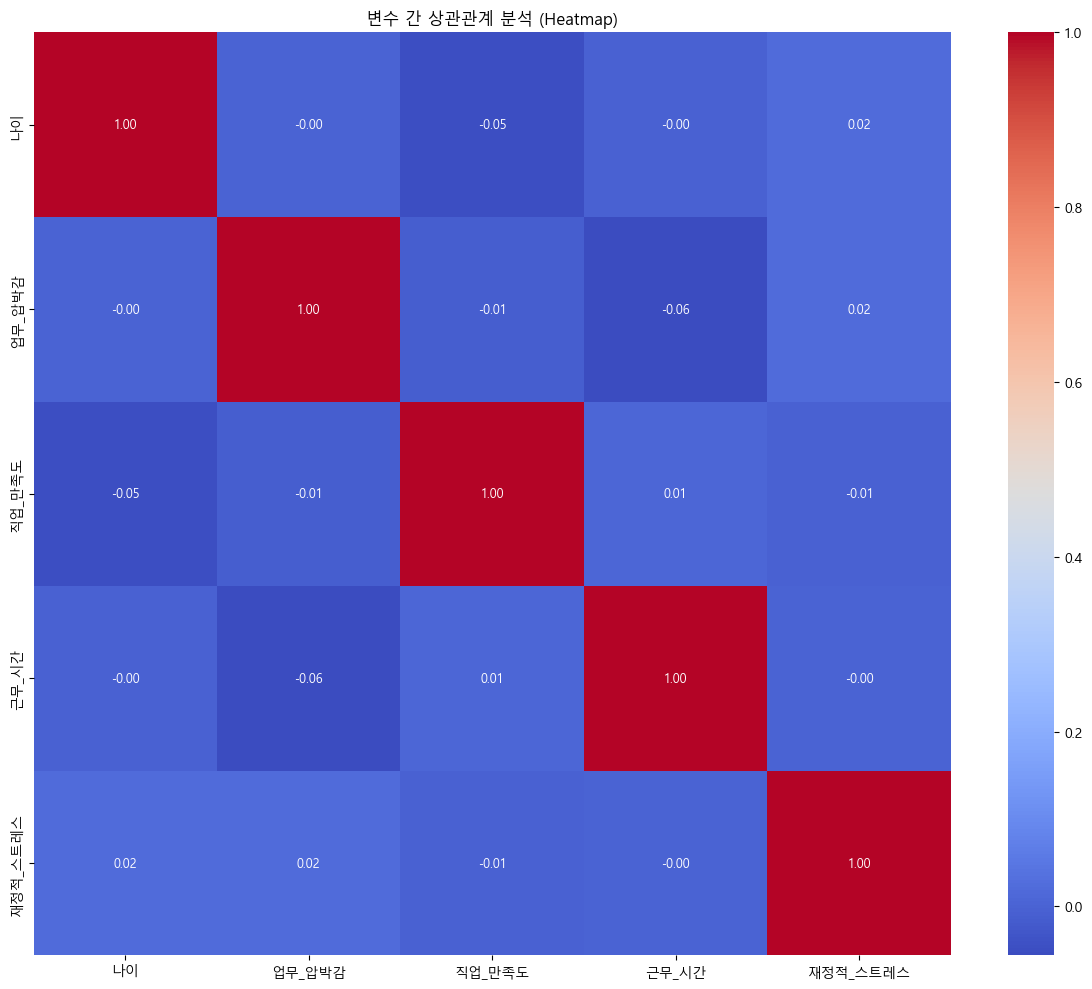

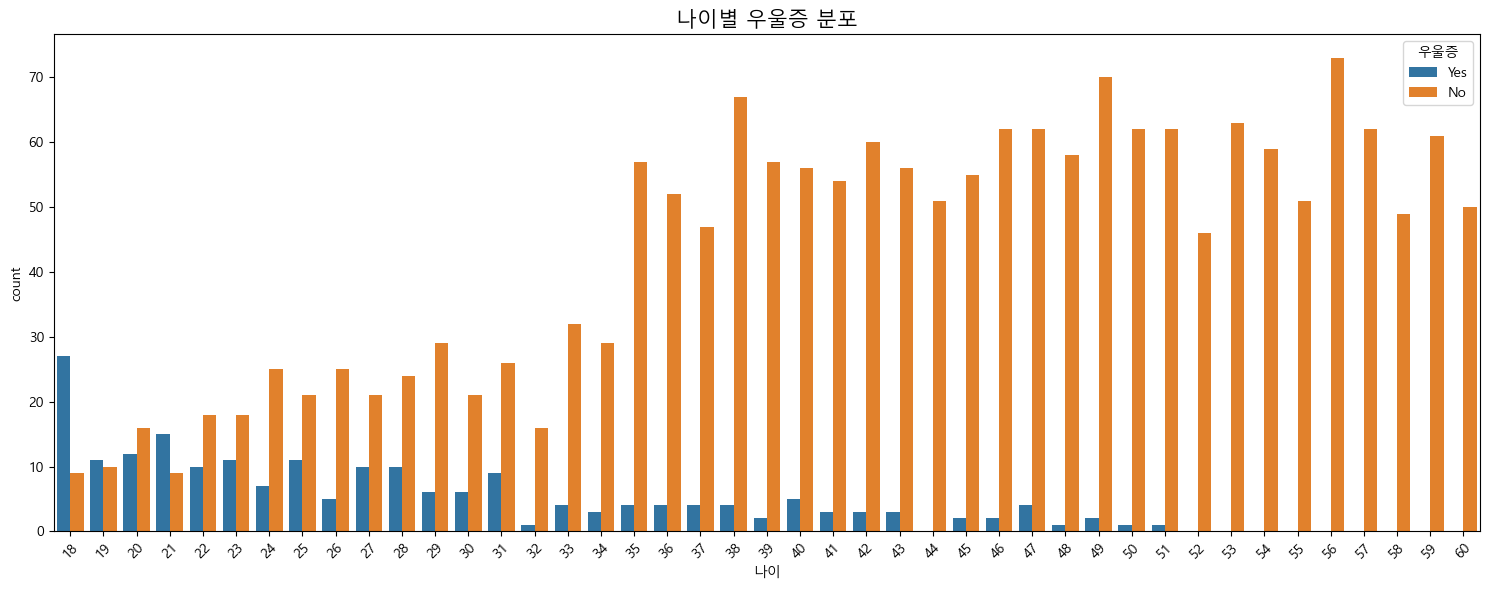


AI 모델 학습을 시작합니다...


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


학습 완료! 시각화를 진행합니다.



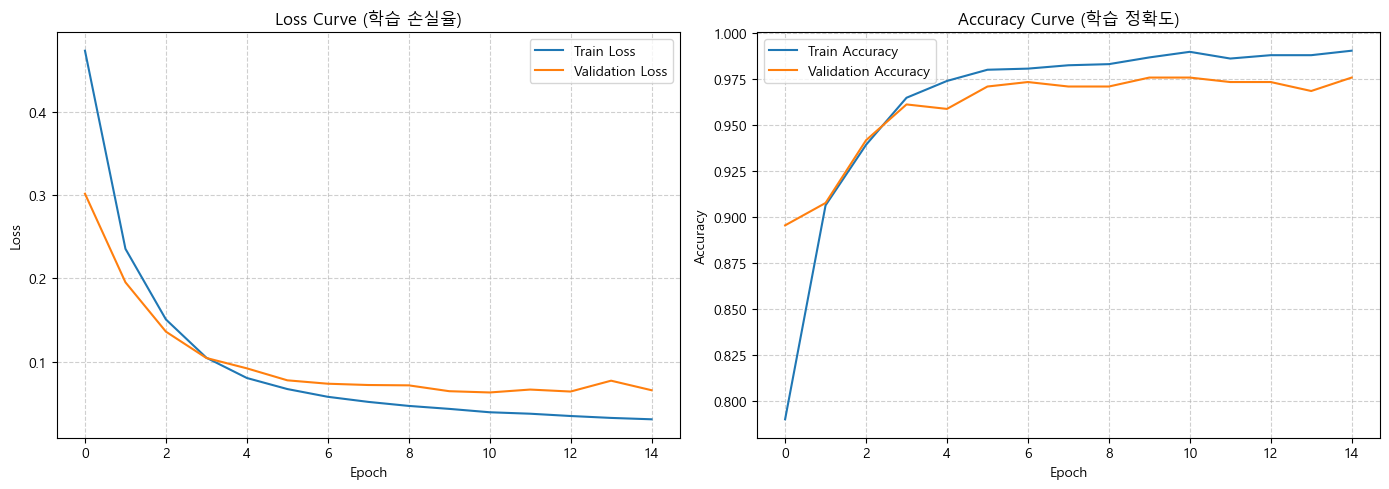

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


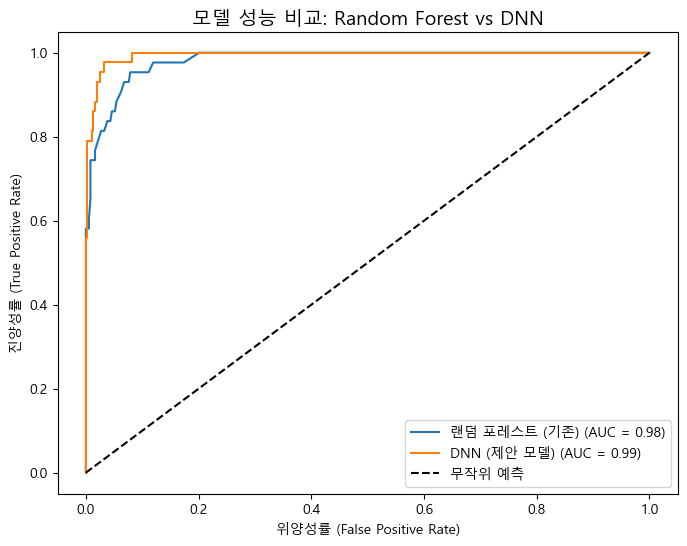


SHAP 분석 중...


c:\Python310\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
c:\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(100, 10))']
  warnings.warn(msg)
c:\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(200, 10))']
  warnings.warn(msg)
c:\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_10
Received: inputs=['Tensor(shape=(50, 10))']
  warnings.warn(msg)
C:\Users\hjn10\AppData\Lo

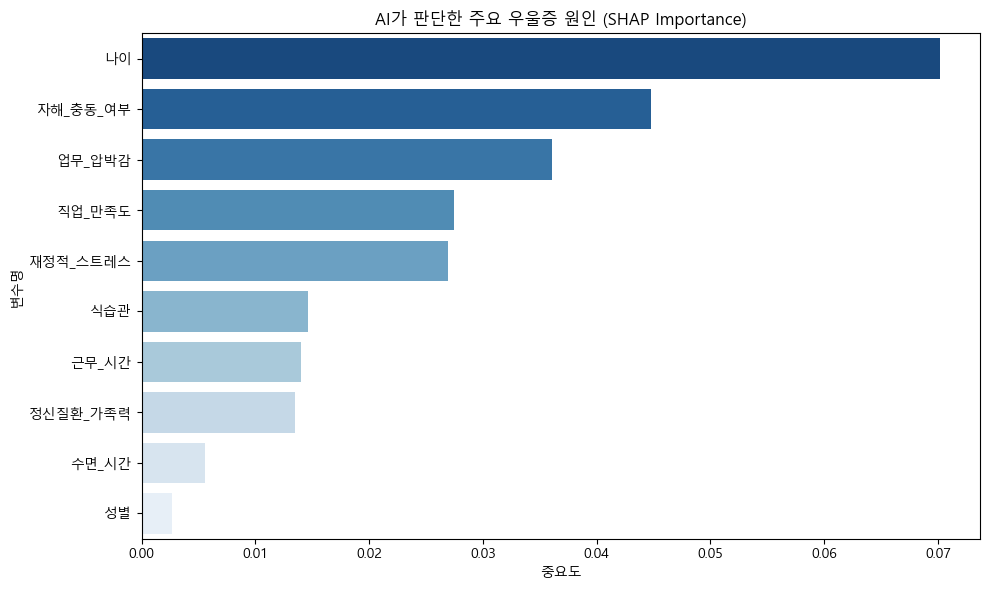


✅ depression_model.h5 파일이 성공적으로 저장되었습니다!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
import tensorflow as tf
import shap
import os

# 텐서플로우 경고 메시지 숨기기
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# --------------------------------------------------------
# 1. 한글 폰트 깨짐 방지 및 폰트 크기 설정
# --------------------------------------------------------
if os.name == 'nt': # 윈도우 사용자
    plt.rc('font', family='Malgun Gothic')
else: # 맥(Mac) 사용자
    plt.rc('font', family='AppleGothic')

plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
plt.rcParams.update({'font.size': 10}) # 전체 폰트 기본 크기 조정

# --------------------------------------------------------
# 2. 데이터 로드 및 한국어 컬럼 설정
# --------------------------------------------------------
df = pd.read_csv('Depression.csv')

# 컬럼 이름을 한국어로 변경
df.columns = [
    '성별', '나이', '업무_압박감', '직업_만족도', '수면_시간', 
    '식습관', '자해_충동_여부', '근무_시간', '재정적_스트레스', 
    '정신질환_가족력', '우울증'
]

# --------------------------------------------------------
# 3. 탐색적 데이터 분석 (EDA)
# --------------------------------------------------------
print("--- [기초 통계량] ---")
print(df.describe())

print("\n--- [데이터 무결성 검사] ---")
print("결측값 개수:\n", df.isnull().sum())
print(f"\n중복된 데이터 개수: {df.duplicated().sum()}개")

# 3-1. 변수 간 상관관계 분석 (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 9}) 
plt.title('변수 간 상관관계 분석 (Heatmap)')
plt.tight_layout()
plt.show()

# 3-2. 주요 변수 분포 (나이별 우울증 분포)
plt.figure(figsize=(15, 6))
sns.countplot(x='나이', hue='우울증', data=df)
plt.title('나이별 우울증 분포', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 4. 데이터 전처리
# --------------------------------------------------------
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('우울증', axis=1)
y = df['우울증']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --------------------------------------------------------
# 5. 모델 학습 (★ 에폭(Epoch) 15로 수정 ★)
# --------------------------------------------------------
print("\nAI 모델 학습을 시작합니다...")

# 랜덤 포레스트 학습 (비교용)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train) 

# DNN(심층 신경망) 모델 구성 (기존 구조 유지)
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# epochs=60 에서 15로 변경하여 과적합 방지
history = dnn_model.fit(
    X_train_scaled, y_train, 
    epochs=15, 
    validation_data=(X_test_scaled, y_test), 
    verbose=0
)

print("학습 완료! 시각화를 진행합니다.\n")

# --------------------------------------------------------
# 6. 시각화 1: Loss & Accuracy Curve
# --------------------------------------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss Curve (학습 손실율)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy Curve (학습 정확도)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 7. 시각화 2: 모델 성능 비교 (ROC Curve)
# --------------------------------------------------------
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1] 
dnn_probs = dnn_model.predict(X_test_scaled).ravel()

plt.figure(figsize=(8, 6))

for name, probs in [('랜덤 포레스트 (기존)', rf_probs), ('DNN (제안 모델)', dnn_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='무작위 예측')
plt.xlabel('위양성률 (False Positive Rate)')
plt.ylabel('진양성률 (True Positive Rate)')
plt.title('모델 성능 비교: Random Forest vs DNN', fontsize=14) 
plt.legend(loc='lower right')
plt.show()

# --------------------------------------------------------
# 8. 시각화 3: SHAP 분석 (Feature Importance)
# --------------------------------------------------------
print("\nSHAP 분석 중...")
explainer = shap.DeepExplainer(dnn_model, X_train_scaled[:100])
shap_values = explainer.shap_values(X_test_scaled[:50])
shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values

mean_shap_values = np.abs(shap_vals).mean(axis=0).flatten()
importance_df = pd.DataFrame({'변수명': list(X.columns), '중요도': mean_shap_values}).sort_values(by='중요도', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='중요도', y='변수명', data=importance_df, palette='Blues_r')
plt.title('AI가 판단한 주요 우울증 원인 (SHAP Importance)')
plt.tight_layout()
plt.show()

# --------------------------------------------------------
# 9. 최종 모델 저장
# --------------------------------------------------------
dnn_model.save('depression_model.h5')
print("\n✅ depression_model.h5 파일이 성공적으로 저장되었습니다!")


혼동 행렬(Confusion Matrix)을 시각화합니다...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


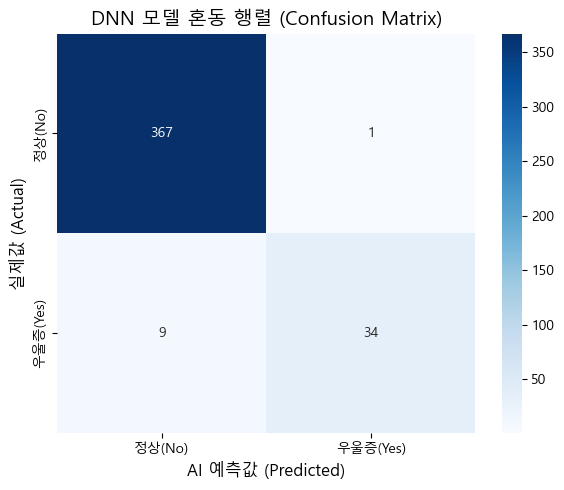

In [6]:
# --------------------------------------------------------
# 7-2. 시각화 추가: 혼동 행렬 (Confusion Matrix)
# --------------------------------------------------------
print("\n혼동 행렬(Confusion Matrix)을 시각화합니다...")

# 1. DNN 모델의 예측 클래스 도출 (확률이 0.5 이상이면 우울증(1), 아니면 정상(0))
dnn_preds = (dnn_model.predict(X_test_scaled) > 0.5).astype("int32")

# 2. 혼동 행렬 계산
cm_dnn = confusion_matrix(y_test, dnn_preds)

# 3. 혼동 행렬 시각화 (Heatmap)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dnn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['정상(No)', '우울증(Yes)'], 
            yticklabels=['정상(No)', '우울증(Yes)'])

plt.title('DNN 모델 혼동 행렬 (Confusion Matrix)', fontsize=14)
plt.xlabel('AI 예측값 (Predicted)', fontsize=12)
plt.ylabel('실제값 (Actual)', fontsize=12)
plt.tight_layout()
plt.show()